In [1]:
from jaxcurve import LearnableCurve
from jaxcurveimpls import BezierCurve
import jax
import jax.numpy as jnp
from tqdm import tqdm, trange
import equinox as eqx

In [2]:
key = jax.random.key(44062)
curve = BezierCurve(32, [0, 0, 0], key)

/home/bobby/CS/quantum/AnalogQSP2/jaxcurveimpls.py:34: UserWarning: Explicitly requested dtype float64 requested in asarray is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  endpoint = jnp.asarray(endpoint, dtype=jnp.float64)


[0. 0. 0.] [0. 0. 0.]
2.6659467


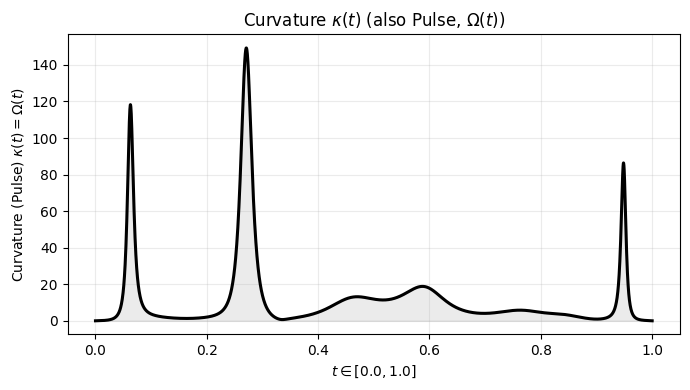

In [3]:
print( curve.position(1), curve.position(0) )
print( curve.arclength() )
curve.plot_curvature()

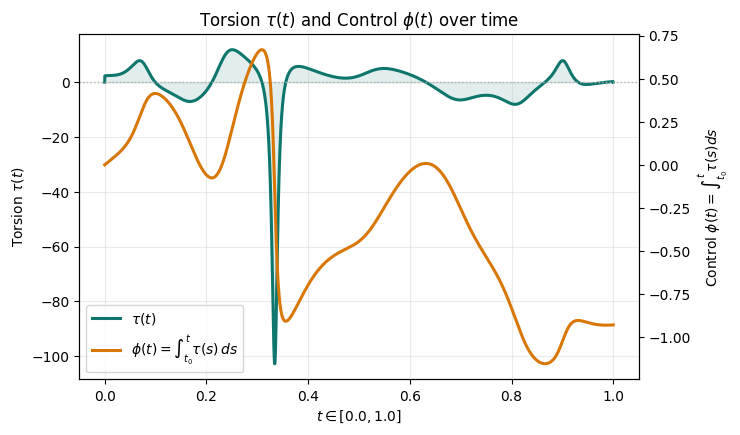

In [4]:
curve.plot_torsion()

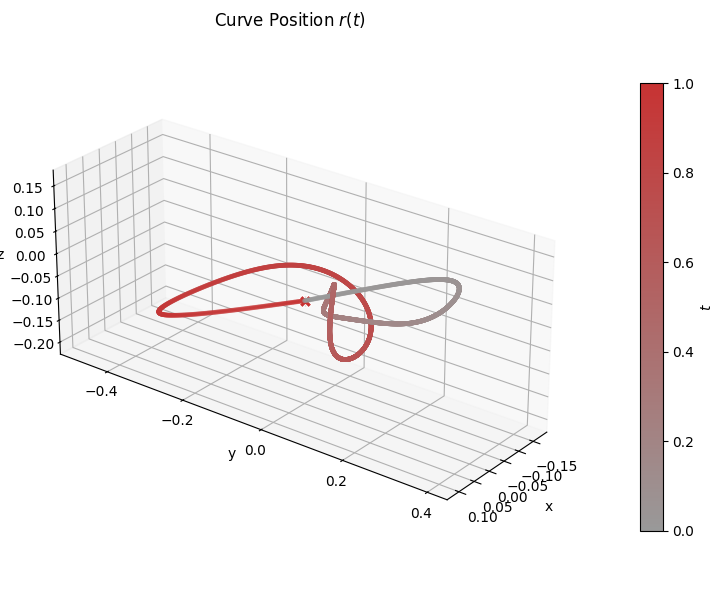

In [5]:
curve.plot_position()

In [ ]:
def cost_fn( c: LearnableCurve, k: jnp.ndarray ):
    m2 = 2048 * jnp.linalg.norm(c.magnus(2, k, 10_000) - jnp.array([0, 0, -1/6])) # -1/6
    m3 = 8192 * jnp.linalg.norm(c.magnus(3, k, 10_000) - jnp.array([0, 0, 0])) # 0
    m4 = 4096 * jnp.linalg.norm(c.magnus(4, k, 10_000) - jnp.array([0, 0, 1/120])) # 1/120
    m5 = 8192 * jnp.linalg.norm(c.magnus(5, k, 10_000) - jnp.array([0, 0, 0])) # 0
    m6 = 16384 * jnp.linalg.norm(c.magnus(6, k, 10_000) - jnp.array([0, 0, -1/5040])) # 1/120

    return m2 + m3 + m4 + m5 + m6

STEPS = 300_000

bar = tqdm(total=STEPS)

def callback( step, loss, curve ):
    bar.set_postfix_str( f"Loss : {loss}" )
    bar.update(1)

curve : BezierCurve = curve.optimize(cost_fn, key, steps=STEPS, lr=1e-3, callback=callback)

100%|█████████▉| 99999/100000 [04:20<00:00, 427.30it/s, Loss : 13.970457077026367]

In [ ]:
print( curve.magnus(2, key, 8192) )
print( curve.magnus(3, key, 8192) )
print( curve.magnus(4, key, 8192) )
print( curve.magnus(5, key, 8192) )
print( curve.magnus(6, key, 8192) )

[ 0.00068866  0.00066713 -0.1725554 ]
[-7.6606344e-03 -8.6419447e-04  1.0240765e-05]
[-3.3133863e-05 -2.4835768e-05  7.6207682e-03]


1.3062841


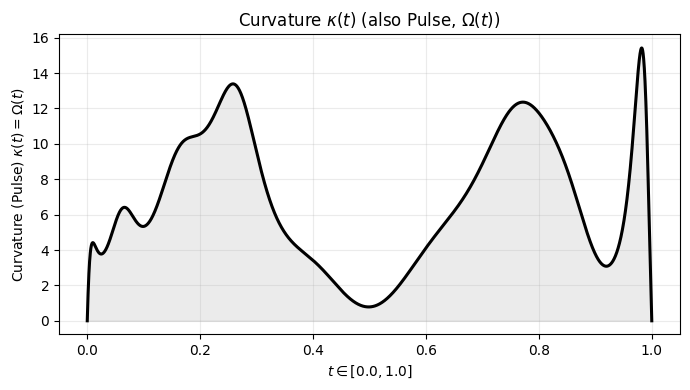

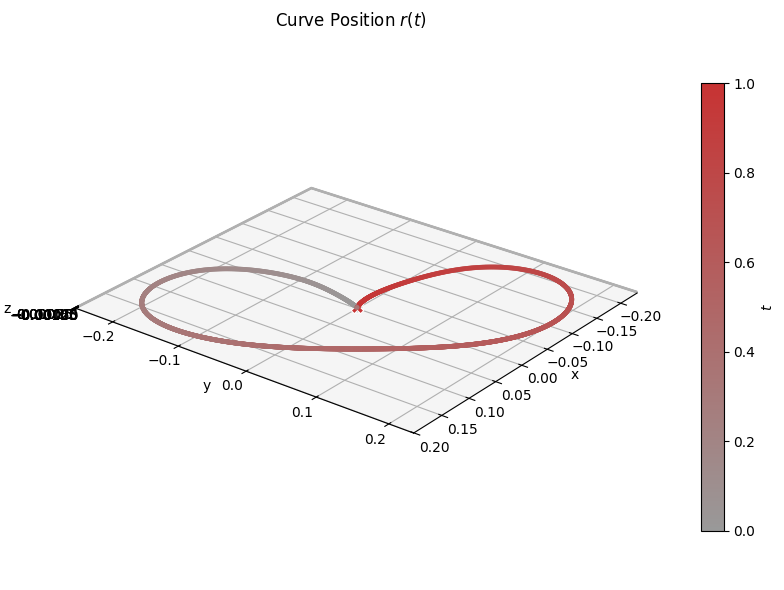

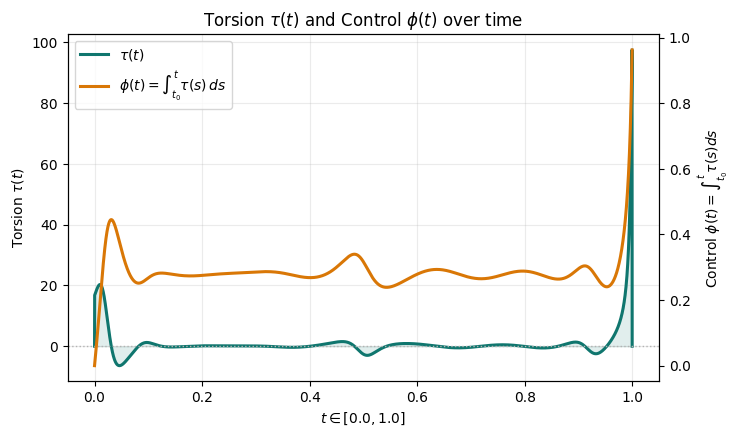

In [8]:
print(curve.arclength())
curve.plot_curvature()
curve.plot_position()
curve.plot_torsion()

In [9]:
eqx.tree_serialise_leaves('bezier.eqx', curve)

In [21]:
import diffrax

In [22]:
@jax.jit
def sig_x():
    return jnp.array([[0, 1], [1, 0]], dtype=jnp.complex64)

@jax.jit
def sig_y():
    return jnp.array([[0, -1j], [1j, 0]], dtype=jnp.complex64)

@jax.jit
def sig_z():
    return jnp.array([[1, 0], [0, -1]], dtype=jnp.complex64)

@jax.jit
def make_traceless_H(a, b, c):
    return sig_x() * a + sig_y() * b + sig_z() * c

H_input = make_traceless_H( *jax.random.uniform(key, (3,), maxval=0.33) )
print(H_input)


[[ 0.25341028+0.j         0.16919579-0.3100879j]
 [ 0.16919579+0.3100879j -0.25341028+0.j       ]]


In [35]:
class CompiledControls( eqx.Module ):
    curve: LearnableCurve
    U_I: diffrax.Solution
    samples: int = eqx.field(static=True)

    def __init__(self, curve: LearnableCurve, samples=4096):
        self.curve = curve
        self.samples = samples

        @eqx.filter_jit
        def drive_system(t: float, U: jnp.ndarray, args):
            curve : LearnableCurve = args['curve']

            curvature = curve.curvature(t).astype(dtype=jnp.complex64) /2
            phi = curve.phi(t).astype(jnp.complex64)

            H = curvature * ( jnp.cos(phi) * sig_x() + jnp.sin(phi) * sig_y() )

            return -1j * H @ U

        self.U_I = diffrax.diffeqsolve( 
            diffrax.ODETerm(drive_system), 
            diffrax.Dopri5(), 
            0, self.curve.tf,
            dt0=self.curve.tf/self.samples,
            y0=jnp.eye(2, dtype=jnp.complex64),
            args={ "curve" : self.curve },
            saveat=diffrax.SaveAt(dense=True)
        )

    def __call__(self, H_in : jnp.ndarray):

        @eqx.filter_jit
        def interaction_system(t: float, U: jnp.ndarray, args):
            U_I : diffrax.Solution = args["U_I"]
            ui_t : jnp.ndarray = jnp.asarray(U_I.evaluate(t))

            H_input : jnp.ndarray = args["H_input"]

            ham = jnp.kron( H_input, ui_t @ sig_z() @ ui_t.T.conj() )

            return -1j * ham @ U
        
        result = diffrax.diffeqsolve(
            diffrax.ODETerm(interaction_system),
            diffrax.Dopri5(),
            0, self.curve.tf, 
            dt0=self.samples,
            y0=jnp.eye( H_in.shape[0] * 2, dtype=jnp.complex64 ),
            args={ "U_I" : self.U_I, "H_input" : H_in },
            progress_meter=diffrax.TqdmProgressMeter()
        )

        return result

In [36]:
system = CompiledControls(curve)

In [37]:
sim_unitary = system(H_input)

print( sim_unitary )

100.00%|██████████| [00:00<00:00, 5804.30%/s]

Solution(
  t0=f32[],
  t1=f32[],
  ts=f32[1],
  ys=c64[1,4,4],
  interpolation=None,
  stats={
    'max_steps': 4096,
    'num_accepted_steps': weak_i32[],
    'num_rejected_steps': weak_i32[],
    'num_steps': weak_i32[]
  },
  result=diffrax._solution.RESULTS<>,
  solver_state=None,
  controller_state=None,
  made_jump=None,
  event_mask=None
)


In [41]:
unitary =  jnp.asarray(sim_unitary.ys)[0] 

print(unitary)

[[ 0.837912  +0.03185596j -0.04237824+0.02452071j  0.04543567+0.02509723j
  -0.01586536+0.052636j  ]
 [ 0.04237822+0.02452078j  0.8379121 -0.03185585j  0.03567682-0.0418261j
  -0.04569267-0.02462586j]
 [-0.04569284+0.02462598j -0.03567681-0.04182614j  0.83829707-0.04261611j
   0.03481815+0.00833035j]
 [ 0.01586535+0.05263599j  0.04543552-0.02509719j -0.03481819+0.00833045j
   0.83829725+0.04261601j]]


In [42]:
pow2 : jnp.ndarray = jnp.linalg.matrix_power( H_input, 2 )
pow4 : jnp.ndarray = jnp.linalg.matrix_power( H_input, 4 )

expected = jax.scipy.linalg.expm( -1j * jnp.kron( jnp.eye(2) - 1j * pow2/6 - 1j * pow4/120 , sig_z() ) )

print(expected)

[[ 5.2339232e-01-8.1513530e-01j  0.0000000e+00+0.0000000e+00j
  -5.7779304e-10-7.2729919e-11j  0.0000000e+00+0.0000000e+00j]
 [ 0.0000000e+00+0.0000000e+00j  5.5775857e-01+8.6865765e-01j
   0.0000000e+00+0.0000000e+00j -3.2671021e-10+5.2762922e-10j]
 [ 3.0657990e-10+4.9511933e-10j  0.0000000e+00+0.0000000e+00j
   5.2339232e-01-8.1513530e-01j  0.0000000e+00+0.0000000e+00j]
 [ 0.0000000e+00+0.0000000e+00j  6.1573135e-10-7.7505440e-11j
   0.0000000e+00+0.0000000e+00j  5.5775857e-01+8.6865765e-01j]]


In [44]:
print( unitary - expected )
print( jnp.linalg.norm( unitary-expected ) )

[[ 0.3145197 +0.84699124j -0.04237824+0.02452071j  0.04543567+0.02509723j
  -0.01586536+0.052636j  ]
 [ 0.04237822+0.02452078j  0.2801535 -0.9005135j   0.03567682-0.0418261j
  -0.04569267-0.02462586j]
 [-0.04569284+0.02462598j -0.03567681-0.04182614j  0.31490475+0.7725192j
   0.03481815+0.00833035j]
 [ 0.01586535+0.05263599j  0.04543552-0.02509719j -0.03481819+0.00833045j
   0.28053868-0.82604164j]]
1.7868824
